**Owner: Jeff**

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

#### Approach

Goal: take a resident's short text description of an item and return one of the 9 waste categories. Part 5 calls this through `classify_waste_description(description)`.

Plan for this section:

1. Start from the team text pipeline built in Part 1 (1.3b) and extend it with regional-term normalisation and lemmatisation.
2. Compare three model families of increasing complexity on the same split:
   - TF-IDF with classical classifiers (Option A), tuned with cross-validated grid search
   - A bidirectional LSTM that learns its own word embeddings (the RNN route)
   - DistilBERT with every layer fine-tuned (Option B)
3. Pick the final model with a rule fixed before touching the test set, then evaluate it once on test.
4. Study the errors: which descriptions are hard and why.

In [46]:
# Setup: imports, seeds, device and paths
import os, re, copy, time, random, pathlib, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

SEED = 42

def set_seed(seed=SEED):
    """Seed every random number generator we use so runs are repeatable."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

# Use a GPU when there is one (CUDA or Apple MPS), otherwise CPU
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)

# Find waste_descriptions.csv: in a data/ folder (repo layout) or next to the notebook,
# searching the current folder and its parents
here = pathlib.Path.cwd()
candidates = [d / sub / "waste_descriptions.csv" for d in [here, *here.parents] for sub in ("data", ".")]
DATA_PATH = next((c.resolve() for c in candidates if c.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("waste_descriptions.csv not found. Put it next to this notebook or in a data/ folder.")
print("Data:", DATA_PATH)

# WordNet data for the lemmatiser (downloads once, then cached)
for pkg in ["wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

# 5-fold stratified CV, reused by every classical experiment
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

Device: cpu
Data: C:\Users\kirukuwaweru\Desktop\DSPT-15\MODULE 5\Ecosort-Waste-Management-System\data\waste_descriptions.csv


### 3.1 Preprocess Text Data

Part 1 explored this file and built the team text pipeline (1.3b). Recap of what matters here:

- 5,000 rows, 9 categories, roughly balanced (506 to 600 per class).
- Descriptions are short and templated: a few modifiers (condition, size, colour, a brand word) followed by the item, e.g. *"crumpled transparent tin can"*.
- `material_composition` and `disposal_instruction` give the label away, so the classifier sees the `description` column only.
- The team pipeline lowercases, removes punctuation and a short domain stopword list, drops duplicates on the cleaned text, and splits 70/15/15 (stratified, seed 42).

#### 3.1a Load the data

This section runs on its own (in `sections/`) and inside the master notebook. When Part 1 has already run, the cells below check that Part 3 uses exactly the same labels, stopwords and split.

In [47]:
# 3.1a Load the descriptions and fix the label order
text_raw = pd.read_csv(DATA_PATH)

# Label order: sorted category names, the same rule Parts 1 and 2 use
text_categories = sorted(text_raw["category"].unique())
if "CATEGORIES" in globals():   # set by Part 1 when running the master notebook
    assert text_categories == CATEGORIES, "Text categories do not match the image class order"
CATEGORIES = text_categories
LABEL2ID = {c: i for i, c in enumerate(CATEGORIES)}
ID2LABEL = {i: c for c, i in LABEL2ID.items()}
NUM_CLASSES = len(CATEGORIES)

print(f"{len(text_raw):,} descriptions | {NUM_CLASSES} categories: {CATEGORIES}")
print("Exact duplicate descriptions:", text_raw["description"].duplicated().sum())
text_raw["category"].value_counts().loc[CATEGORIES].to_frame("rows")

5,000 descriptions | 9 categories: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Exact duplicate descriptions: 61


,rows
category,
Cardboard,584
Food Organics,518
Glass,551
Metal,508
Miscellaneous Trash,578
Paper,506
Plastic,569
Textile Trash,586
Vegetation,600


#### 3.1b Normalisation, tokenisation and lemmatisation

The team pipeline is the base. Part 3 adds two steps on top, both aimed at how residents actually write.

**Regional terminology.** The dataset brief mentions regional terminology variations. Every description in the CSV uses one spelling (e.g. *aluminum*, *diaper*, *styrofoam*), so a resident who types *aluminium*, *nappy* or *polystyrene* would hit words the model never saw. A small normalisation map rewrites common regional or alternative terms onto the wording used in the training data. Every target on the right-hand side is a word that exists in the training vocabulary.

**Lemmatisation.** WordNet lemmatisation maps plurals onto one form (*leaves* → *leaf*, *bags* → *bag*), so the model does not have to learn two features for one item.

| Step | What it does | Example | Source |
|---|---|---|---|
| Lowercase | removes case differences such as *Brand A* / *brand a* | *Commercial* → *commercial* | team pipeline (1.3b) |
| Split compounds | hyphens and slashes become spaces | *t-shirt* → *t shirt*, *CD/DVD* → *cd dvd* | team pipeline (1.3b) |
| Letters only | digits and punctuation removed | *yesterday's* → *yesterday s* | team pipeline (1.3b) |
| Regional terms | map onto training vocabulary | *carrier bag* → *plastic bag* | Part 3 |
| Tokenise | NLTK `RegexpTokenizer` | | Part 3 |
| Domain stopwords | drop articles, prepositions and auxiliaries only; keeps label words such as *can* and *six* | *sheet of paper* → *sheet paper* | team pipeline (1.3b) |
| Lemmatise | WordNet, so plurals share one feature | *leaves* → *leaf* | Part 3 |

Two versions of the text are kept. `clean` (all steps) feeds TF-IDF and the BiLSTM. `text` stops after the regional mapping and keeps every word, and it feeds DistilBERT: a pretrained transformer works best on natural word order, and its WordPiece tokeniser handles plurals itself.

In [48]:
# 3.1b Normalisation, tokenisation and lemmatisation
# Regional / alternative terms mapped onto the wording used in the training data.
# Only targets the model has seen are useful, so every value is a word in the training vocabulary.
REGIONAL_TERMS = {
    "aluminium": "aluminum",
    "jumper": "sweater",
    "woollen": "wool", "woolen": "wool",
    "nappies": "diaper", "nappy": "diaper",
    "polystyrene": "styrofoam",
    "takeaway": "takeout",
    "cling film": "plastic wrap", "clingfilm": "plastic wrap", "saran wrap": "plastic wrap",
    "kitchen roll": "paper towel",
    "biro": "pen",
    "sellotape": "tape", "scotch tape": "tape",
    "carrier bag": "plastic bag", "bin bag": "plastic bag", "bin liner": "plastic bag",
    "fizzy drink": "soda",
    "tee shirt": "t shirt", "tshirt": "t shirt",
    "mobile phone": "electronic device", "cell phone": "electronic device", "cellphone": "electronic device",
    "cigarette end": "cigarette butt",
}
# Longest phrases first, so "carrier bag" is replaced before any shorter overlapping term
_REGIONAL_RE = re.compile(
    r"\b(" + "|".join(sorted(map(re.escape, REGIONAL_TERMS), key=len, reverse=True)) + r")\b"
)

def normalize_text(text):
    """Lowercase, split hyphen/slash compounds, keep letters only, map regional terms."""
    t = str(text).lower()
    t = re.sub(r"[-/]", " ", t)          # t-shirt -> t shirt, cd/dvd -> cd dvd
    t = re.sub(r"[^a-z\s]", " ", t)      # no digits or punctuation in the training data
    t = re.sub(r"\s+", " ", t).strip()
    return _REGIONAL_RE.sub(lambda m: REGIONAL_TERMS[m.group(0)], t)

TOKENIZER = RegexpTokenizer(r"[a-z]+")
LEMMATIZER = WordNetLemmatizer()

# Domain stopword list from the team pipeline (Part 1, 1.3b): articles, prepositions and auxiliaries only.
# Label words such as 'can' (always Metal) and 'six' (always Cardboard) are kept, as are 'not' and 'no'.
MIN_STOPWORDS = {
    "a", "an", "the", "of", "with", "and", "or", "in", "on", "at", "for", "to", "from", "by",
    "is", "are", "was", "were", "be", "been", "has", "have", "had", "it", "its", "this", "that",
    "my", "our", "s",
}
if "STOP" in globals():   # Part 1 has run (master notebook): both parts must use the same list
    assert MIN_STOPWORDS == set(STOP), "Stopword list differs from the team pipeline in Part 1"

def base_clean(text):
    """The team pipeline from Part 1 (1.3b): lowercase, letters only, domain stopwords removed."""
    t = re.sub(r"[^a-z\s]", " ", str(text).lower())
    return " ".join(w for w in t.split() if w not in MIN_STOPWORDS).strip()

def tokenize_text(text):
    """Full pipeline: normalise -> tokenise -> drop stopwords -> lemmatise."""
    return [LEMMATIZER.lemmatize(tok)
            for tok in TOKENIZER.tokenize(normalize_text(text))
            if tok not in MIN_STOPWORDS]

def preprocess_bow(text):
    """Space-joined tokens, the input format for TF-IDF and the BiLSTM."""
    return " ".join(tokenize_text(text))

# Show each step on a few awkward inputs
examples = ["Brand A t-shirt", "empty CD/DVD case", "crumpled aluminium can", "dry six-pack holder",
            "fallen leaves", "torn small purple tea bags", "yesterday's newspaper",
            "used nappies in a carrier bag"]
pd.DataFrame({"raw": examples,
              "team pipeline (1.3b)": [base_clean(e) for e in examples],
              "text (DistilBERT)": [normalize_text(e) for e in examples],
              "clean (TF-IDF / LSTM)": [preprocess_bow(e) for e in examples]})

,raw,team pipeline (1.3b),text (DistilBERT),clean (TF-IDF / LSTM)
0,Brand A t-shirt,brand t shirt,brand a t shirt,brand t shirt
1,empty CD/DVD case,empty cd dvd case,empty cd dvd case,empty cd dvd case
2,crumpled aluminium can,crumpled aluminium can,crumpled aluminum can,crumpled aluminum can
3,dry six-pack holder,dry six pack holder,dry six pack holder,dry six pack holder
4,fallen leaves,fallen leaves,fallen leaves,fallen leaf
5,torn small purple tea bags,torn small purple tea bags,torn small purple tea bags,torn small purple tea bag
6,yesterday's newspaper,yesterday newspaper,yesterday s newspaper,yesterday newspaper
7,used nappies in a carrier bag,used nappies carrier bag,used diaper in a plastic bag,used diaper plastic bag


#### 3.1c Clean, de-duplicate and split

In [49]:
# 3.1c Clean, de-duplicate and split (stratified 70/15/15, same as Part 1)
# Build the modelling table: description only, plus both processed versions and an integer label
text_df = text_raw[["description", "category"]].copy()
text_df["text"] = text_df["description"].map(normalize_text)    # DistilBERT input
text_df["clean"] = text_df["description"].map(preprocess_bow)   # TF-IDF / BiLSTM input
text_df["label"] = text_df["category"].map(LABEL2ID)

# Safety check: no cleaned string is shared by two different categories
assert text_df.groupby("clean")["category"].nunique().max() == 1, "Cleaning merged items from different classes"

before = len(text_df)
text_df = text_df.drop_duplicates(subset="clean").reset_index(drop=True)
print(f"Removed {before - len(text_df)} duplicates on the cleaned text -> {len(text_df)} rows")
print("Tokens per cleaned description: max", text_df["clean"].str.split().str.len().max(),
      "| mean", round(text_df["clean"].str.split().str.len().mean(), 1))

# Same stratified 70/15/15 split and seed as Part 1
text_train_df, text_hold_df = train_test_split(text_df, test_size=0.30, stratify=text_df["category"], random_state=SEED)
text_val_df, text_test_df = train_test_split(text_hold_df, test_size=0.50, stratify=text_hold_df["category"], random_state=SEED)
text_train_df, text_val_df, text_test_df = (d.reset_index(drop=True) for d in (text_train_df, text_val_df, text_test_df))

# Confirm the rows match the team split from Part 1 (1.3b).
# In the master notebook Part 1's train_txt exists; on its own, rebuild it the same way.
if "train_txt" in globals():
    team_train = train_txt
else:
    team = text_raw[["description", "category"]].copy()
    team["clean"] = team["description"].map(base_clean)
    team = team.drop_duplicates(subset="clean").reset_index(drop=True)
    team_train, _ = train_test_split(team, test_size=0.30, stratify=team["category"], random_state=SEED)
print("Train rows identical to the team split (Part 1):", set(team_train["description"]) == set(text_train_df["description"]))

split_counts = pd.DataFrame({name: d["category"].value_counts()
                             for name, d in [("train", text_train_df), ("val", text_val_df), ("test", text_test_df)]}).loc[CATEGORIES]
split_counts.loc["TOTAL"] = split_counts.sum()
split_counts

Removed 61 duplicates on the cleaned text -> 4939 rows
Tokens per cleaned description: max 11 | mean 4.9
Train rows identical to the team split (Part 1): True


,train,val,test
category,,,
Cardboard,407,87,87
Food Organics,358,77,76
Glass,379,81,81
Metal,353,76,75
Miscellaneous Trash,404,86,87
Paper,347,74,75
Plastic,388,83,84
Textile Trash,409,88,88
Vegetation,412,89,88


The split is row-for-row the same as Part 1's, so Part 5 can treat `text_test_df` as the shared text test set. The `text_` prefix keeps these names from clashing with the image data frames in other parts of the master notebook. Validation is used for every modelling decision. The test set is used once, at the end.

#### 3.1d Challenging descriptions

Looking at which words appear in which categories shows two built-in traps:

- **Material distractors.** Some descriptions contain a material word that points to the wrong class. *"travel-sized pink glass silk tie"* is Textile Trash, *"dirty medium cardboard plastic-metal composite"* is Miscellaneous Trash. The item noun decides the label, the material adjective is noise.
- **Shared nouns.** Some item nouns belong to several classes and only the neighbouring word separates them: *egg shells* (Food Organics) vs *egg carton* (Cardboard), *paper towel* (Paper) vs *cotton towel* (Textile Trash), *soda can* (Metal) vs *soda bottle* (Plastic), *vegetable waste* (Food Organics) vs *garden waste* (Vegetation).

We flag both groups so every model can be scored on them separately in 3.3.

In [50]:
# 3.1d Flag challenging descriptions
# Material words and the class they would suggest on their own
MATERIAL_HINTS = {
    "glass": "Glass", "plastic": "Plastic", "metal": "Metal", "aluminum": "Metal", "steel": "Metal",
    "tin": "Metal", "copper": "Metal", "paper": "Paper", "cardboard": "Cardboard",
    "fabric": "Textile Trash", "cotton": "Textile Trash", "wool": "Textile Trash",
    "silk": "Textile Trash", "polyester": "Textile Trash", "leather": "Textile Trash",
}

# Which categories each (cleaned) word appears in, from the training split only
word_cats = {}
for s, c in zip(text_train_df["clean"], text_train_df["category"]):
    for w in set(s.split()):
        word_cats.setdefault(w, set()).add(c)

# Shared nouns: words found in 2-4 classes. Modifiers (colours, sizes, conditions) appear in 7-9 classes,
# so this range picks out ambiguous item nouns (bottle, egg, towel) plus a few secondary materials (bamboo, rubber).
SHARED_NOUNS = sorted(w for w, cs in word_cats.items() if 2 <= len(cs) <= 4 and w not in MATERIAL_HINTS)
print("Shared nouns:", SHARED_NOUNS)

def add_flags(d):
    toks = d["clean"].str.split()
    d["distractor"] = [any(t in MATERIAL_HINTS and MATERIAL_HINTS[t] != c for t in ts)
                       for ts, c in zip(toks, d["category"])]
    d["shared_noun"] = toks.apply(lambda ts: any(t in SHARED_NOUNS for t in ts))
    return d

for d in (text_train_df, text_val_df, text_test_df):
    add_flags(d)

print(pd.DataFrame({name: [d["distractor"].sum(), d["shared_noun"].sum(), len(d)]
                    for name, d in [("train", text_train_df), ("val", text_val_df), ("test", text_test_df)]},
                   index=["material distractor", "shared noun", "total rows"]))
print("\nDistractor examples:")
print(text_train_df.loc[text_train_df["distractor"], ["description", "category"]].head(6).to_string(index=False))

Shared nouns: ['bag', 'bamboo', 'biodegradable', 'bottle', 'case', 'cd', 'ceramic', 'composite', 'container', 'cup', 'cutlery', 'egg', 'holder', 'lid', 'packaging', 'piece', 'rubber', 'scrap', 'sheet', 'silicone', 'soda', 'synthetic', 'towel', 'toy', 'tray', 'tube', 'vegetable', 'waste', 'wooden']
                     train  val  test
material distractor    210   40    41
shared noun           1351  272   323
total rows            3457  741   741

Distractor examples:
                                                       description            category
                    dirty medium cardboard plastic-metal composite Miscellaneous Trash
                                        crumpled toilet paper roll           Cardboard
regular-sized gold plastic Artisanal baby clothes partially filled       Textile Trash
                                  travel-sized pink glass silk tie       Textile Trash
                                          torn black fabric CD/DVD Miscellaneous Trash
     

#### 3.1e Hand-written challenge set

The CSV is synthetic and very regular, so near-perfect test scores are expected and say little about real residents. We wrote 28 descriptions the way people actually type: regional words, full sentences, a negation, unknown words (*banana skin*, *lawn*, *rusty*), and the distractor and shared-noun patterns above. Some regional items are covered by the normalisation map and some are not, so the set also shows what the map can and cannot fix.

This set is small and written by us, so we treat it as a robustness check, not a benchmark. It is used to compare models and preprocessing choices, never for training.

In [51]:
# 3.1e Hand-written challenge set
CHALLENGE = [
    ("aluminium tin of baked beans",            "Metal"),
    ("old woollen jumper with holes",           "Textile Trash"),
    ("used nappy",                              "Miscellaneous Trash"),
    ("polystyrene block from a tv box",         "Miscellaneous Trash"),
    ("cling film that was covering leftovers",  "Plastic"),
    ("kitchen roll soaked in cooking oil",      "Paper"),
    ("biro that ran out of ink",                "Miscellaneous Trash"),
    ("half a roll of sellotape",                "Miscellaneous Trash"),
    ("carrier bag from the supermarket",        "Plastic"),
    ("empty fizzy drink can",                   "Metal"),
    ("broken mobile phone",                     "Miscellaneous Trash"),
    ("cigarette end",                           "Miscellaneous Trash"),
    ("egg shells from breakfast",               "Food Organics"),
    ("egg carton",                              "Cardboard"),
    ("paper towel",                             "Paper"),
    ("cotton bath towel",                       "Textile Trash"),
    ("green glass wine bottle",                 "Glass"),
    ("plastic shampoo bottle",                  "Plastic"),
    ("t-shirt with a glass print",              "Textile Trash"),
    ("grass cuttings from mowing the lawn",     "Vegetation"),
    ("banana skin",                             "Food Organics"),
    ("yesterday's newspaper",                   "Paper"),
    ("flattened shipping box",                  "Cardboard"),
    ("dead AA battery",                         "Miscellaneous Trash"),
    ("rusty steel nail",                        "Metal"),
    ("not plastic, it's a glass jar",           "Glass"),
    ("toilet roll tube",                        "Cardboard"),
    ("greasy pizza box",                        "Cardboard"),
]
challenge_df = pd.DataFrame(CHALLENGE, columns=["description", "category"])
assert set(challenge_df["category"]) <= set(CATEGORIES)
print(len(challenge_df), "challenge descriptions")
challenge_df["category"].value_counts()

28 challenge descriptions


category
Miscellaneous Trash    7
Cardboard              4
Metal                  3
Textile Trash          3
Plastic                3
Paper                  3
Food Organics          2
Glass                  2
Vegetation             1
Name: count, dtype: int64

### 3.2 Implement Text Classification Model

Three model families, each chosen for a reason:

| Model | Why it is here |
|---|---|
| TF-IDF + classical classifier (Option A) | Strong, fast baseline for short keyword-driven text. The label mostly depends on one item noun, which bag-of-words captures well. Bigrams give it some word-pair context (*egg carton* vs *egg shells*). |
| BiLSTM with learned embeddings | The RNN route from the brief. It learns its own word embeddings and reads the sequence in both directions, so it can use word order instead of counting words. |
| DistilBERT, all layers fine-tuned (Option B) | Pretrained on general English, so it brings knowledge of words the CSV never uses. WordPiece splits unknown words into known pieces, which matters for free-form resident input. DistilBERT keeps about 97% of BERT's language understanding with 40% fewer parameters, so full fine-tuning is affordable. |

#### 3.2a Option A: TF-IDF + classical classifiers

TF-IDF on unigrams and bigrams. We search over four classifiers with 5-fold stratified cross-validation on the training split, scored by macro-F1 so every class counts equally:

- **Multinomial Naive Bayes**: the standard text baseline; `alpha` controls smoothing.
- **Logistic Regression**: linear, gives calibrated probabilities (useful for Part 5's confidence score); `C` controls regularisation.
- **Linear SVM**: often the strongest linear text classifier; no native probabilities.
- **Random Forest**: non-linear, included to test whether word interactions add anything.

In [52]:
# 3.2a Option A: TF-IDF pipelines and search grids
def tfidf_pipeline(clf):
    # Input is already tokenised and joined by spaces, so split on whitespace only.
    # This keeps single letters such as the 't' in 't shirt'.
    return Pipeline([("tfidf", TfidfVectorizer(token_pattern=r"\S+")), ("clf", clf)])

CLASSICAL_SEARCH = {
    "Multinomial NB": (
        tfidf_pipeline(MultinomialNB()),
        {"tfidf__ngram_range": [(1, 1), (1, 2)], "tfidf__sublinear_tf": [False, True],
         "clf__alpha": [0.01, 0.1, 0.5, 1.0]}),
    "Logistic Regression": (
        tfidf_pipeline(LogisticRegression(max_iter=5000)),
        {"tfidf__ngram_range": [(1, 1), (1, 2)], "tfidf__sublinear_tf": [False, True],
         "clf__C": [1, 10, 100]}),
    "Linear SVM": (
        tfidf_pipeline(LinearSVC()),
        {"tfidf__ngram_range": [(1, 1), (1, 2)], "tfidf__sublinear_tf": [False, True],
         "clf__C": [0.1, 1, 10]}),
    "Random Forest": (
        tfidf_pipeline(RandomForestClassifier(random_state=SEED, n_jobs=-1)),
        {"tfidf__ngram_range": [(1, 1), (1, 2)], "clf__n_estimators": [300],
         "clf__max_depth": [None, 30], "clf__min_samples_leaf": [1, 2]}),
}
for name, (_, grid) in CLASSICAL_SEARCH.items():
    print(f"{name}: {int(np.prod([len(v) for v in grid.values()]))} configurations x 5 folds")

Multinomial NB: 16 configurations x 5 folds
Logistic Regression: 12 configurations x 5 folds
Linear SVM: 12 configurations x 5 folds
Random Forest: 8 configurations x 5 folds


#### 3.2b BiLSTM with learned word embeddings

Architecture:

- **Embedding layer** (vocabulary built from the training split only, index 0 for padding, index 1 for unknown words). These are the word embeddings the brief asks for, learned from this data.
- **Bidirectional LSTM**. Reading in both directions means the representation of *egg* can depend on whether *carton* or *shells* follows it.
- **Classifier**: the last forward and last backward hidden states are concatenated, then dropout and a linear layer to 9 classes.

Sequences are packed with `pack_padded_sequence`, so padding never reaches the LSTM and the final hidden state belongs to the last real token.

In [53]:
# 3.2b BiLSTM: vocabulary, data loading and model
# Vocabulary from the training split only (no peeking at val/test words)
token_counts = Counter(tok for s in text_train_df["clean"] for tok in s.split())
VOCAB = {"<pad>": 0, "<unk>": 1}
for tok, _ in token_counts.most_common():
    VOCAB[tok] = len(VOCAB)
MAX_TOKENS = 32   # training texts have at most 11 tokens; room for longer resident input
print("Vocabulary size (incl. <pad>, <unk>):", len(VOCAB))

def encode(clean_text):
    """Cleaned text -> list of token ids. Unknown words map to <unk>."""
    ids = [VOCAB.get(tok, VOCAB["<unk>"]) for tok in clean_text.split()][:MAX_TOKENS]
    return ids or [VOCAB["<unk>"]]   # the LSTM needs at least one step

class SeqDataset(Dataset):
    def __init__(self, clean_texts, labels):
        self.ids = [encode(t) for t in clean_texts]
        self.labels = list(labels)
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, i):
        return self.ids[i], self.labels[i]

def pad_collate(batch):
    """Pad a batch to its longest sequence and keep the true lengths for packing."""
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs])
    padded = torch.zeros(len(seqs), int(lengths.max()), dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = torch.tensor(s)
    return padded, lengths, torch.tensor(labels)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * hidden_dim, num_classes)

    def forward(self, ids, lengths):
        x = self.dropout(self.embedding(ids))
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        h = torch.cat([h[-2], h[-1]], dim=1)   # last forward state + last backward state
        return self.fc(self.dropout(h))

# Packed LSTMs are not reliable on Apple MPS, so the LSTM runs on CUDA or CPU (it is small either way)
LSTM_DEVICE = DEVICE if DEVICE.type == "cuda" else torch.device("cpu")

Vocabulary size (incl. <pad>, <unk>): 303


#### 3.2c Option B: DistilBERT, full fine-tune

- Checkpoint: `distilbert-base-uncased`, with a new 9-way classification head.
- **All layers are trainable**: embeddings, the 6 transformer blocks and the head. The cell below confirms that trainable parameters equal total parameters.
- Input is `text` (normalised, regional terms mapped, stopwords kept).
- Batches are padded to the longest description in the batch. The maximum length is 64 WordPiece tokens: training descriptions are far shorter, and the extra room covers longer resident sentences.

In [54]:
# 3.2c Option B: DistilBERT tokenizer, data loading and model
BERT_NAME = "distilbert-base-uncased"
BERT_MAX_LEN = 64

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
wp_lens = [len(ids) for ids in bert_tokenizer(text_train_df["text"].tolist())["input_ids"]]
print(f"WordPiece tokens per training description (incl. [CLS]/[SEP]): max {max(wp_lens)}, mean {np.mean(wp_lens):.1f}")
print("Example:", text_train_df["text"].iloc[0], "->", bert_tokenizer.tokenize(text_train_df["text"].iloc[0]))

class PairDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts, self.labels = list(texts), list(labels)
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, i):
        return self.texts[i], self.labels[i]

def bert_collate(batch):
    """Tokenise a batch and pad it to its longest member."""
    texts, labels = zip(*batch)
    enc = bert_tokenizer(list(texts), padding=True, truncation=True,
                         max_length=BERT_MAX_LEN, return_tensors="pt")
    enc["labels"] = torch.tensor(labels)
    return enc

def load_bert():
    return AutoModelForSequenceClassification.from_pretrained(
        BERT_NAME, num_labels=NUM_CLASSES, id2label=ID2LABEL, label2id=LABEL2ID)

# Confirm every layer will be fine-tuned
_m = load_bert()
total_params = sum(p.numel() for p in _m.parameters())
trainable_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"DistilBERT parameters: {total_params:,} total | {trainable_params:,} trainable")
assert total_params == trainable_params
del _m

WordPiece tokens per training description (incl. [CLS]/[SEP]): max 17, mean 7.6
Example: industrial greeting card with food residue -> ['industrial', 'greeting', 'card', 'with', 'food', 'residue']


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT parameters: 66,960,393 total | 66,960,393 trainable


### 3.3 Train and Evaluate the Model

Training: 3.3a to 3.3d. Evaluation: 3.3e to 3.3g.

#### 3.3a Which preprocessing steps earn their place?

We hold the model fixed (TF-IDF unigrams+bigrams, Logistic Regression, C=10) and add the preprocessing steps one at a time: lowercase only, then the team cleaning from 1.3b, then the regional-term map, then lemmatisation. Each version is scored three ways: 5-fold CV on train, validation macro-F1, and accuracy on the challenge set.

In [55]:
# 3.3a Preprocessing ablation: add one step at a time
def regional_clean(text):
    """Team cleaning + regional-term map, without lemmatisation."""
    return " ".join(w for w in normalize_text(text).split() if w not in MIN_STOPWORDS)

# Each step adds one thing to the step before it
PREPROCESSORS = {
    "1. lowercase only": lambda t: str(t).lower(),
    "2. + team cleaning (1.3b)": base_clean,
    "3. + regional terms": regional_clean,
    "4. + lemmatisation (final)": preprocess_bow,
}

ablation = []
for name, fn in PREPROCESSORS.items():
    pipe = Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), token_pattern=r"(?u)\b\w+\b")),
                     ("clf", LogisticRegression(C=10, max_iter=5000))])
    X_tr = text_train_df["description"].map(fn)
    cv_scores = cross_val_score(pipe, X_tr, text_train_df["category"], cv=CV, scoring="f1_macro")
    pipe.fit(X_tr, text_train_df["category"])
    val_pred = pipe.predict(text_val_df["description"].map(fn))
    ch_pred = pipe.predict(challenge_df["description"].map(fn))
    ablation.append({
        "preprocessing": name,
        "cv_macro_f1": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "val_macro_f1": f1_score(text_val_df["category"], val_pred, average="macro"),
        "challenge_acc": accuracy_score(challenge_df["category"], ch_pred),
        "challenge_misses": [d for d, p, t in zip(challenge_df["description"], ch_pred, challenge_df["category"]) if p != t],
    })

ablation_df = pd.DataFrame(ablation)
pd.set_option("display.max_colwidth", 200)
ablation_df.round(4)

,preprocessing,cv_macro_f1,cv_std,val_macro_f1,challenge_acc,challenge_misses
0,1. lowercase only,0.9974,0.0011,0.9946,0.7500,"[polystyrene block from a tv box, cling film that was covering leftovers, kitchen roll soaked in cooking oil, biro that ran out of ink, half a roll of sellotape, carrier bag from the supermarket, ..."
1,2. + team cleaning (1.3b),0.9974,0.0011,0.9933,0.7500,"[polystyrene block from a tv box, cling film that was covering leftovers, kitchen roll soaked in cooking oil, biro that ran out of ink, half a roll of sellotape, carrier bag from the supermarket, ..."
2,3. + regional terms,0.9974,0.0011,0.9933,0.9643,[polystyrene block from a tv box]
3,4. + lemmatisation (final),0.9974,0.0011,0.9946,0.9643,[polystyrene block from a tv box]


On the CSV itself every version scores the same (0.997 CV macro-F1, 0.993 to 0.995 on validation, a difference of one row). The data is so templated that the item nouns survive any reasonable cleaning.

The challenge set shows where the gain comes from:

| Step | Challenge accuracy | What changes |
|---|---|---|
| 1. lowercase only | 21/28 | regional words (*cling film*, *kitchen roll*, *biro*, *sellotape*, *carrier bag*, *mobile phone*) are unknown |
| 2. + team cleaning | 21/28 | same; removing articles and prepositions neither helps nor hurts |
| 3. + regional terms | 27/28 | six of the seven misses are fixed; *polystyrene* now maps to *styrofoam*, but *box* still wins |
| 4. + lemmatisation | 27/28 | no change on the challenge set; recovers one validation row |

The regional-term map is the step that matters for real resident wording. The team cleaning keeps the label words (*can*, *six*), so *"empty fizzy drink can"* is classified correctly from step 1 onwards. Lemmatisation adds little measurable gain on this data but is kept, since it costs nothing and stops plural forms (*tea bags*, *tea bag*) becoming separate features. The one remaining miss, *"polystyrene block from a tv box"*, has *box* pulling towards Cardboard. The tuned model in 3.3e gets it right.

We use the full pipeline (step 4) for everything that follows.

#### 3.3b Train the classical models (grid search)

In [56]:
# 3.3b Train the classical models with cross-validated grid search
classical_searches, classical_rows = {}, []
for name, (pipe, grid) in CLASSICAL_SEARCH.items():
    t0 = time.time()
    gs = GridSearchCV(pipe, grid, cv=CV, scoring="f1_macro", n_jobs=-1)
    gs.fit(text_train_df["clean"], text_train_df["category"])
    val_pred = gs.predict(text_val_df["clean"])
    classical_searches[name] = gs
    classical_rows.append({
        "model": name,
        "configs_tried": len(gs.cv_results_["params"]),
        "best_cv_macro_f1": gs.best_score_,
        "val_accuracy": accuracy_score(text_val_df["category"], val_pred),
        "val_macro_f1": f1_score(text_val_df["category"], val_pred, average="macro"),
        "search_seconds": round(time.time() - t0, 1),
        "best_params": gs.best_params_,
    })

classical_df = pd.DataFrame(classical_rows).sort_values("best_cv_macro_f1", ascending=False)
classical_df.round(4)

,model,configs_tried,best_cv_macro_f1,val_accuracy,val_macro_f1,search_seconds,best_params
1,Logistic Regression,12,0.9997,1.0000,1.0000,7.8,"{'clf__C': 100, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': False}"
2,Linear SVM,12,0.9997,0.9960,0.9961,2.1,"{'clf__C': 10, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': False}"
0,Multinomial NB,16,0.9910,0.9906,0.9905,7.3,"{'clf__alpha': 0.1, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': False}"
3,Random Forest,8,0.9815,0.9825,0.9826,31.6,"{'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300, 'tfidf__ngram_range': (1, 2)}"


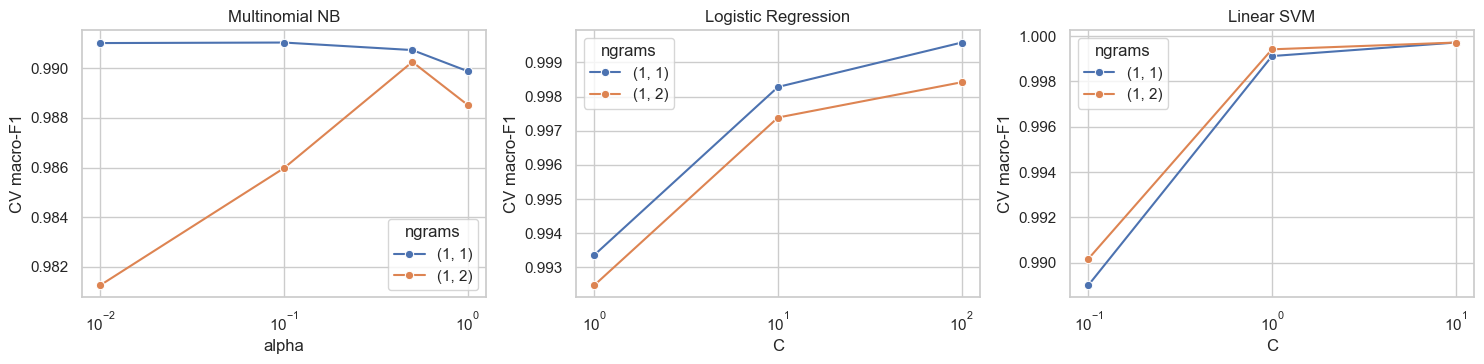

Classical champion: Logistic Regression {'clf__C': 100, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': False}


In [57]:
# 3.3b Hyperparameter sensitivity and classical champion
# How sensitive is each model to its main hyperparameter? (mean CV macro-F1 across the other settings)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (name, param) in zip(axes, [("Multinomial NB", "param_clf__alpha"),
                                     ("Logistic Regression", "param_clf__C"),
                                     ("Linear SVM", "param_clf__C")]):
    res = pd.DataFrame(classical_searches[name].cv_results_)
    res["ngrams"] = res["param_tfidf__ngram_range"].astype(str)
    sns.lineplot(data=res, x=param, y="mean_test_score", hue="ngrams", marker="o", ax=ax, errorbar=None)
    ax.set_xscale("log"); ax.set_title(name); ax.set_xlabel(param.replace("param_clf__", "")); ax.set_ylabel("CV macro-F1")
plt.tight_layout(); plt.show()

# Pick the classical champion: best CV score, validation macro-F1 as tie-breaker
best_classical_name = max(classical_searches, key=lambda n: (
    round(classical_searches[n].best_score_, 4),
    f1_score(text_val_df["category"], classical_searches[n].predict(text_val_df["clean"]), average="macro")))
classical_model = classical_searches[best_classical_name].best_estimator_
if not hasattr(classical_model, "predict_proba"):
    # Linear SVM has no probabilities; calibrate it so Part 5 still gets a confidence score
    classical_model = CalibratedClassifierCV(classical_model, cv=5).fit(text_train_df["clean"], text_train_df["category"])
print("Classical champion:", best_classical_name, classical_searches[best_classical_name].best_params_)

In [58]:
# 3.3b Top features per class (Logistic Regression)
# What has the linear model learned? Top-weighted features per class
lr_pipe = classical_searches["Logistic Regression"].best_estimator_
features = np.array(lr_pipe.named_steps["tfidf"].get_feature_names_out())
coefs = lr_pipe.named_steps["clf"].coef_
top_features = pd.DataFrame({c: features[np.argsort(coefs[i])[::-1][:8]] for i, c in enumerate(lr_pipe.classes_)})
top_features

,Cardboard,Food Organics,Glass,Metal,Miscellaneous Trash,Paper,Plastic,Textile Trash,Vegetation
0,box,peel,glass,metal,pencil,paper,plastic,scarf,plant
1,cardboard,bread,bottle,can,tape,notebook,container,hat,leaf
2,packaging,shell,light,steel,pen,envelope,clamshell,glove,flower
3,carton,scrap,bulb,tin,styrofoam,newspaper,toothbrush,curtain,weed
4,roll,pit,mirror,nail,battery,flyer,bottle,tablecloth,branch
5,toilet,tea,fragment,wire,dvd,magazine,shampoo,sock,houseplant
6,carrier,dairy,perfume,cap,tool,receipt,water,rug,garden
7,beverage,bone,champagne,foil,marker,brochure,wrap,carpet,tree


Logistic Regression and Linear SVM tie on cross-validation (about 0.9997) and are ahead of Naive Bayes (about 0.991) and Random Forest (about 0.982). For both Logistic Regression and Linear SVM, strong regularisation (C = 0.1 or 1) costs up to a point of macro-F1, so these short texts need little regularisation. Bigrams never improve the linear models, and they make Naive Bayes worse at low smoothing: the item nouns already carry the label on their own. Random Forest is the weakest and much the slowest, because sparse TF-IDF vectors suit linear boundaries better than tree splits.

The top features are mostly item nouns (*can*, *nail*, *peel*, *scarf*, *battery*), so the model reads the item, not the colour or condition words. The material words (*glass*, *plastic*, *metal*, *paper*, *cardboard*) also rank first or second for their own class. That is the weak spot: a material distractor such as *plastic* in a Textile description pushes the prediction towards the wrong class, which 3.3g confirms. Logistic Regression is kept as the classical champion: it wins the validation tie-break and gives probabilities directly.

#### 3.3c Train the BiLSTM

Adam (lr 2e-3), cross-entropy loss, gradient clipping at 1.0, batch size 64. Early stopping watches validation loss with a patience of 4 epochs, and the best epoch's weights are restored. Four configurations vary embedding size, hidden size and dropout.

In [ ]:
# 3.3c Train the BiLSTM (4 configurations, early stopping)
def make_seq_loader(d, shuffle, batch_size=64):
    g = torch.Generator().manual_seed(SEED)   # same shuffling order every run
    return DataLoader(SeqDataset(d["clean"], d["label"]), batch_size=batch_size,
                      shuffle=shuffle, collate_fn=pad_collate, generator=g)

def lstm_epoch(model, loader, criterion, optimizer=None):
    """One pass over the data. Trains if an optimizer is given, otherwise evaluates."""
    training = optimizer is not None
    model.train(training)
    total_loss, preds, golds = 0.0, [], []
    with torch.set_grad_enabled(training):
        for ids, lengths, labels in loader:
            ids, labels = ids.to(LSTM_DEVICE), labels.to(LSTM_DEVICE)
            logits = model(ids, lengths)
            loss = criterion(logits, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * labels.size(0)
            preds += logits.argmax(1).tolist()
            golds += labels.tolist()
    return total_loss / len(golds), f1_score(golds, preds, average="macro")

def train_lstm(embed_dim, hidden_dim, dropout, lr=2e-3, max_epochs=30, patience=4):
    set_seed()
    model = BiLSTMClassifier(len(VOCAB), embed_dim, hidden_dim, NUM_CLASSES, dropout).to(LSTM_DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_loader, val_loader = make_seq_loader(text_train_df, True), make_seq_loader(text_val_df, False)

    history, best_loss, best_state, wait = [], float("inf"), None, 0
    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_f1 = lstm_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_f1 = lstm_epoch(model, val_loader, criterion)
        history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": va_loss,
                        "train_f1": tr_f1, "val_f1": va_f1})
        if va_loss < best_loss - 1e-4:            # improvement: remember these weights
            best_loss, best_state, wait = va_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:                   # no improvement for `patience` epochs
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

LSTM_GRID = [
    dict(embed_dim=64,  hidden_dim=64,  dropout=0.3),
    dict(embed_dim=128, hidden_dim=64,  dropout=0.3),
    dict(embed_dim=64,  hidden_dim=128, dropout=0.5),
    dict(embed_dim=128, hidden_dim=128, dropout=0.5),
]

lstm_runs = []
for cfg in LSTM_GRID:
    t0 = time.time()
    lstm_candidate, hist = train_lstm(**cfg)
    best = hist.loc[hist["val_loss"].idxmin()]
    lstm_runs.append({**cfg, "epochs_run": len(hist), "best_epoch": int(best["epoch"]),
                      "val_loss": best["val_loss"], "val_macro_f1": best["val_f1"],
                      "seconds": round(time.time() - t0, 1), "model": lstm_candidate, "history": hist})
    print(f"{cfg} -> best epoch {int(best['epoch'])}, val loss {best['val_loss']:.4f}, val macro-F1 {best['val_f1']:.4f}")

best_lstm_run = max(lstm_runs, key=lambda r: (round(r["val_macro_f1"], 4), -r["val_loss"]))
lstm_model = best_lstm_run["model"].eval()
lstm_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("model", "history")} for r in lstm_runs])
lstm_df.round(4)

{'embed_dim': 64, 'hidden_dim': 64, 'dropout': 0.3} -> best epoch 30, val loss 0.0003, val macro-F1 1.0000
{'embed_dim': 128, 'hidden_dim': 64, 'dropout': 0.3} -> best epoch 26, val loss 0.0002, val macro-F1 1.0000
{'embed_dim': 64, 'hidden_dim': 128, 'dropout': 0.5} -> best epoch 22, val loss 0.0007, val macro-F1 1.0000
{'embed_dim': 128, 'hidden_dim': 128, 'dropout': 0.5} -> best epoch 20, val loss 0.0002, val macro-F1 1.0000


,embed_dim,hidden_dim,dropout,epochs_run,best_epoch,val_loss,val_macro_f1,seconds
0,64,64,0.3,30,30,0.0003,1.0,37.5
1,128,64,0.3,29,26,0.0002,1.0,51.5
2,64,128,0.5,26,22,0.0007,1.0,48.4
3,128,128,0.5,24,20,0.0002,1.0,36.1


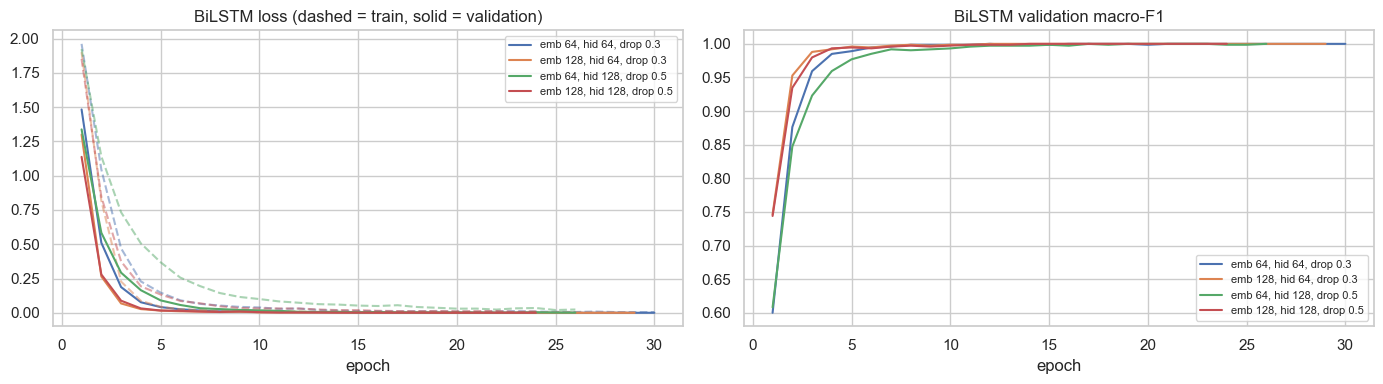

Selected BiLSTM: {'embed_dim': 128, 'hidden_dim': 64, 'dropout': 0.3}


In [60]:
# 3.3c BiLSTM training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for k, r in enumerate(lstm_runs):
    label = f"emb {r['embed_dim']}, hid {r['hidden_dim']}, drop {r['dropout']}"
    h, colour = r["history"], f"C{k}"          # one colour per configuration in both panels
    axes[0].plot(h["epoch"], h["train_loss"], "--", color=colour, alpha=0.5)
    axes[0].plot(h["epoch"], h["val_loss"], color=colour, label=label)
    axes[1].plot(h["epoch"], h["val_f1"], color=colour, label=label)
axes[0].set_title("BiLSTM loss (dashed = train, solid = validation)"); axes[0].set_xlabel("epoch")
axes[1].set_title("BiLSTM validation macro-F1"); axes[1].set_xlabel("epoch")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Selected BiLSTM:", {k: best_lstm_run[k] for k in ("embed_dim", "hidden_dim", "dropout")})

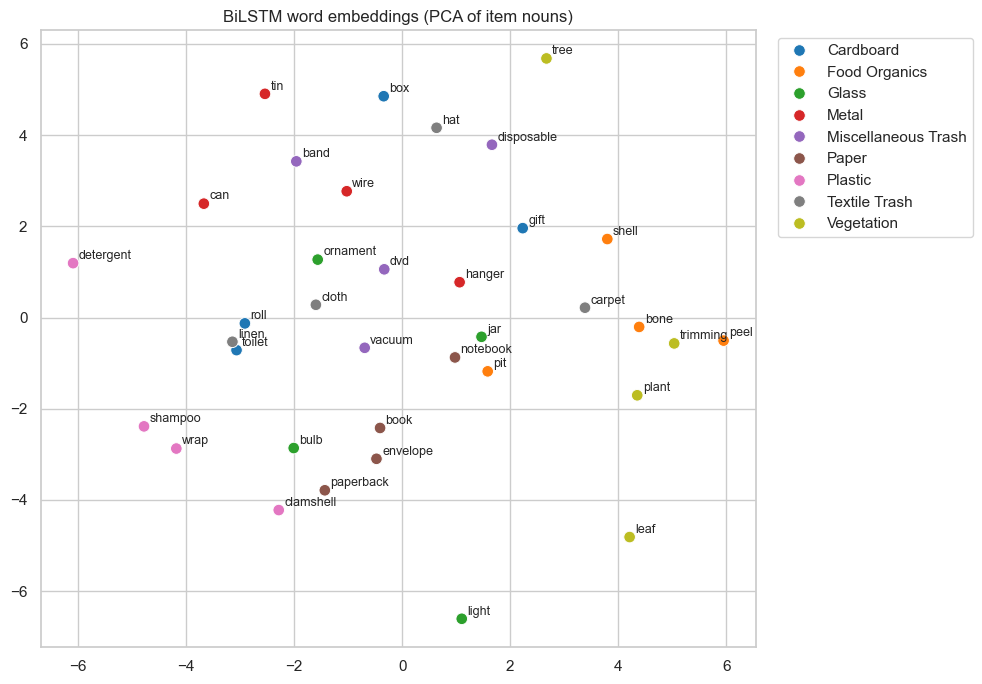

In [61]:
# 3.3c Learned word embeddings
# The learned word embeddings: project item nouns to 2D and colour them by category.
# We take the 4 most frequent words that only ever occur in one category.
emb = lstm_model.embedding.weight.detach().cpu().numpy()
words, word_labels = [], []
for c in CATEGORIES:
    own = sorted((w for w, cs in word_cats.items() if cs == {c}), key=lambda w: -token_counts[w])[:4]
    words += own
    word_labels += [c] * len(own)

coords = PCA(n_components=2, random_state=SEED).fit_transform(emb[[VOCAB[w] for w in words]])
plt.figure(figsize=(10, 7))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=word_labels, hue_order=CATEGORIES, s=70, palette="tab10")
for (x, y), w in zip(coords, words):
    plt.annotate(w, (x, y), xytext=(4, 3), textcoords="offset points", fontsize=9)
plt.title("BiLSTM word embeddings (PCA of item nouns)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

All four configurations reach a validation macro-F1 of 1.0. They are separated by validation loss, and the selection takes the lowest: embedding size 128, hidden size 64, dropout 0.3 (validation loss 0.0002, best epoch 26 of 29). The wider embedding converges faster: it passes 0.99 validation F1 by epoch 4, against epoch 6 for the 64-dimensional version. Dropout 0.5 slows the early epochs (the 64/128 model needs 7 epochs to pass 0.99) without improving the final result. One configuration (64/64) was still improving at the 30-epoch cap, so its stopping point was the cap, not early stopping.

Train and validation loss fall together and stay close, so there is no sign of overfitting. Validation loss is in fact slightly below training loss, because dropout is active during training and off during evaluation.

The embedding plot shows what the model learned about word meaning without being told. Paper items (*book*, *envelope*, *paperback*, *notebook*) group together, as do the plastic items (*shampoo*, *wrap*, *clamshell*). Food Organics and Vegetation words (*peel*, *bone*, *shell*, *plant*, *trimming*, *leaf*) share one region on the right, which makes sense since both are organic. Other categories are more spread out. This is a 2D projection of 128 dimensions, so some separation is lost in the picture.

#### 3.3d Fine-tune DistilBERT

AdamW with weight decay 0.01 (not applied to biases and LayerNorm weights), a linear schedule with 10% warm-up, gradient clipping at 1.0, batch size 32, up to 6 epochs. Early stopping on validation loss with a patience of 2, keeping the best epoch.

The learning rate is the hyperparameter that matters most when fine-tuning a transformer: too high and the pretrained weights are damaged, too low and training stalls. We compare 2e-5, 3e-5 and 5e-5, the range recommended for BERT-family models.

In [ ]:
# 3.3d Fine-tune DistilBERT (learning-rate sweep, early stopping)
BERT_EPOCHS = 6
# The full sweep takes about 60 minutes on CPU. Set to False for a quick re-run (best rate only).
RUN_FULL_BERT_SWEEP = True
BERT_LRS = [2e-5, 3e-5, 5e-5] if RUN_FULL_BERT_SWEEP else [5e-5]

def bert_epoch(model, loader, optimizer=None, scheduler=None):
    """One pass over the data. Trains if an optimizer is given, otherwise evaluates."""
    training = optimizer is not None
    model.train(training)
    total_loss, preds, golds = 0.0, [], []
    with torch.set_grad_enabled(training):
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = model(**batch)
            if training:
                optimizer.zero_grad()
                out.loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
            n = batch["labels"].size(0)
            total_loss += out.loss.item() * n
            preds += out.logits.argmax(-1).tolist()
            golds += batch["labels"].tolist()
    return total_loss / len(golds), f1_score(golds, preds, average="macro")

def train_bert(lr, epochs=BERT_EPOCHS, batch_size=32, patience=2, warmup=0.1, weight_decay=0.01):
    set_seed()
    model = load_bert().to(DEVICE)
    for p in model.parameters():
        p.requires_grad = True        # full fine-tune: embeddings, all transformer blocks, head

    # No weight decay on biases and LayerNorm weights (standard for transformers)
    no_decay = ("bias", "LayerNorm", "layer_norm")
    groups = [
        {"params": [p for n, p in model.named_parameters() if not any(k in n for k in no_decay)],
         "weight_decay": weight_decay},
        {"params": [p for n, p in model.named_parameters() if any(k in n for k in no_decay)],
         "weight_decay": 0.0},
    ]
    optimizer = torch.optim.AdamW(groups, lr=lr)

    g = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(PairDataset(text_train_df["text"], text_train_df["label"]), batch_size=batch_size,
                              shuffle=True, collate_fn=bert_collate, generator=g)
    val_loader = DataLoader(PairDataset(text_val_df["text"], text_val_df["label"]), batch_size=64, collate_fn=bert_collate)

    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, int(warmup * total_steps), total_steps)

    history, best_loss, best_state, wait = [], float("inf"), None, 0
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_f1 = bert_epoch(model, train_loader, optimizer, scheduler)
        va_loss, va_f1 = bert_epoch(model, val_loader)
        history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": va_loss,
                        "train_f1": tr_f1, "val_f1": va_f1, "seconds": time.time() - t0})
        print(f"  lr={lr:.0e} | epoch {epoch} | train loss {tr_loss:.4f} | val loss {va_loss:.4f} "
              f"| val macro-F1 {va_f1:.4f} | {time.time() - t0:.0f}s")
        if va_loss < best_loss - 1e-4:
            best_loss, wait = va_loss, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return best_state, pd.DataFrame(history)

bert_runs, best_bert_run, best_bert_state = [], None, None
for lr in BERT_LRS:
    state, hist = train_bert(lr)
    best = hist.loc[hist["val_loss"].idxmin()]
    run = {"lr": lr, "epochs_run": len(hist), "best_epoch": int(best["epoch"]),
           "val_loss": best["val_loss"], "val_macro_f1": best["val_f1"],
           "minutes": round(hist["seconds"].sum() / 60, 1), "history": hist}
    bert_runs.append(run)
    # keep only the best run's weights in memory
    if best_bert_run is None or (round(run["val_macro_f1"], 4), -run["val_loss"]) > \
                                (round(best_bert_run["val_macro_f1"], 4), -best_bert_run["val_loss"]):
        best_bert_run, best_bert_state = run, state

# Rebuild the best DistilBERT for inference
bert_model = load_bert()
bert_model.load_state_dict(best_bert_state)
bert_model.to(DEVICE).eval()

bert_df = pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in bert_runs])
bert_df["lr"] = bert_df["lr"].map("{:.0e}".format)   # otherwise round(4) shows 2e-5 as 0.0
print(f"Selected learning rate: {best_bert_run['lr']:.0e}")
bert_df.round(4)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  lr=2e-05 | epoch 1 | train loss 1.7930 | val loss 0.7116 | val macro-F1 0.9310 | 168s
  lr=2e-05 | epoch 2 | train loss 0.2815 | val loss 0.0446 | val macro-F1 0.9986 | 199s
  lr=2e-05 | epoch 3 | train loss 0.0357 | val loss 0.0208 | val macro-F1 0.9973 | 155s
  lr=2e-05 | epoch 4 | train loss 0.0183 | val loss 0.0094 | val macro-F1 1.0000 | 160s
  lr=2e-05 | epoch 5 | train loss 0.0129 | val loss 0.0075 | val macro-F1 1.0000 | 164s
  lr=2e-05 | epoch 6 | train loss 0.0107 | val loss 0.0069 | val macro-F1 1.0000 | 168s


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  lr=3e-05 | epoch 1 | train loss 1.5691 | val loss 0.2878 | val macro-F1 0.9784 | 182s
  lr=3e-05 | epoch 2 | train loss 0.0900 | val loss 0.0145 | val macro-F1 1.0000 | 220s
  lr=3e-05 | epoch 3 | train loss 0.0151 | val loss 0.0064 | val macro-F1 1.0000 | 205s
  lr=3e-05 | epoch 4 | train loss 0.0095 | val loss 0.0043 | val macro-F1 1.0000 | 195s
  lr=3e-05 | epoch 5 | train loss 0.0059 | val loss 0.0034 | val macro-F1 1.0000 | 194s
  lr=3e-05 | epoch 6 | train loss 0.0055 | val loss 0.0032 | val macro-F1 1.0000 | 156s


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  lr=5e-05 | epoch 1 | train loss 1.2903 | val loss 0.0639 | val macro-F1 0.9959 | 173s
  lr=5e-05 | epoch 2 | train loss 0.0254 | val loss 0.0054 | val macro-F1 1.0000 | 172s
  lr=5e-05 | epoch 3 | train loss 0.0071 | val loss 0.0025 | val macro-F1 1.0000 | 180s
  lr=5e-05 | epoch 4 | train loss 0.0055 | val loss 0.0017 | val macro-F1 1.0000 | 227s
  lr=5e-05 | epoch 5 | train loss 0.0028 | val loss 0.0014 | val macro-F1 1.0000 | 217s
  lr=5e-05 | epoch 6 | train loss 0.0029 | val loss 0.0013 | val macro-F1 1.0000 | 206s


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Selected learning rate: 5e-05


,lr,epochs_run,best_epoch,val_loss,val_macro_f1,minutes
0,2e-05,6,6,0.0069,1.0,16.9
1,3e-05,6,6,0.0032,1.0,19.2
2,5e-05,6,6,0.0013,1.0,19.6


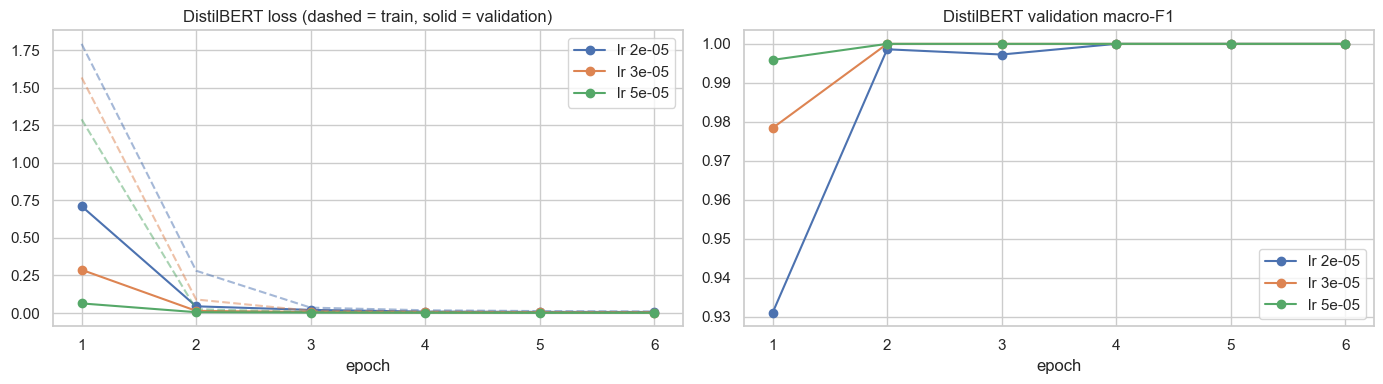

In [63]:
# 3.3d DistilBERT training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for k, r in enumerate(bert_runs):
    h, colour = r["history"], f"C{k}"          # one colour per learning rate in both panels
    axes[0].plot(h["epoch"], h["train_loss"], "--", color=colour, alpha=0.5)
    axes[0].plot(h["epoch"], h["val_loss"], marker="o", color=colour, label=f"lr {r['lr']:.0e}")
    axes[1].plot(h["epoch"], h["val_f1"], marker="o", color=colour, label=f"lr {r['lr']:.0e}")
axes[0].set_title("DistilBERT loss (dashed = train, solid = validation)"); axes[0].set_xlabel("epoch")
axes[1].set_title("DistilBERT validation macro-F1"); axes[1].set_xlabel("epoch")
axes[0].legend(); axes[1].legend()
plt.tight_layout(); plt.show()

All three learning rates reach a validation macro-F1 of 1.0. The higher the rate, the faster it gets there: 5e-5 scores 0.996 after one epoch, 3e-5 scores 0.978 and 2e-5 only 0.931. 5e-5 also gives the lowest validation loss (0.0013), so it is selected. None of the rates damaged the pretrained weights. On data this regular, the usual risk of a high rate does not show up.

Validation loss was still falling slightly at epoch 6 for every rate, so early stopping never triggered. Accuracy had already saturated by epoch 2 to 4, so more epochs would only make the model more confident, not more accurate. We kept 6 epochs because each run takes 17 to 20 minutes on CPU.

#### 3.3e Compare the models and choose the final one

All three models are wrapped behind the same interface: a function that takes raw descriptions and returns a probability matrix with columns in `CATEGORIES` order. Comparison, evaluation and the final function then work the same way for any model.

**Selection rule, fixed before looking at the test set:**

1. Shortlist every model within 0.005 of the best validation macro-F1. Differences smaller than that come down to one or two validation rows.
2. From the shortlist, take the model with the highest challenge-set accuracy, because robustness to real wording is what Part 5 needs.
3. If still tied, take the faster model.

In [64]:
# 3.3e Model comparison on validation + challenge set, final model selection
def classical_predict_proba(texts):
    """Raw descriptions -> class probabilities from the TF-IDF champion."""
    proba = classical_model.predict_proba([preprocess_bow(t) for t in texts])
    order = [list(classical_model.classes_).index(c) for c in CATEGORIES]
    return proba[:, order]

@torch.no_grad()
def lstm_predict_proba(texts, batch_size=256):
    """Raw descriptions -> class probabilities from the BiLSTM."""
    lstm_model.eval()
    seqs = [encode(preprocess_bow(t)) for t in texts]
    out = []
    for i in range(0, len(seqs), batch_size):
        ids, lengths, _ = pad_collate([(s, 0) for s in seqs[i:i + batch_size]])
        out.append(torch.softmax(lstm_model(ids.to(LSTM_DEVICE), lengths), dim=1).cpu().numpy())
    return np.vstack(out)

@torch.no_grad()
def bert_predict_proba(texts, batch_size=64):
    """Raw descriptions -> class probabilities from DistilBERT."""
    bert_model.eval()
    out = []
    for i in range(0, len(texts), batch_size):
        chunk = [normalize_text(t) for t in texts[i:i + batch_size]]
        enc = bert_tokenizer(chunk, padding=True, truncation=True,
                             max_length=BERT_MAX_LEN, return_tensors="pt").to(DEVICE)
        out.append(torch.softmax(bert_model(**enc).logits, dim=-1).cpu().numpy())
    return np.vstack(out)

CANDIDATES = {
    f"TF-IDF + {best_classical_name}": classical_predict_proba,
    "BiLSTM (learned embeddings)": lstm_predict_proba,
    "DistilBERT (full fine-tune)": bert_predict_proba,
}

def predict_df(fn, d):
    proba = fn(d["description"].tolist())
    return proba, np.array(CATEGORIES)[proba.argmax(1)]

comparison, challenge_preds = [], {}
for name, fn in CANDIDATES.items():
    t0 = time.perf_counter()
    _, val_pred = predict_df(fn, text_val_df)
    ms_per_text = (time.perf_counter() - t0) / len(text_val_df) * 1000
    _, ch_pred = predict_df(fn, challenge_df)
    challenge_preds[name] = ch_pred
    comparison.append({
        "model": name,
        "val_accuracy": accuracy_score(text_val_df["category"], val_pred),
        "val_macro_f1": f1_score(text_val_df["category"], val_pred, average="macro"),
        "val_acc_distractor": accuracy_score(text_val_df.loc[text_val_df["distractor"], "category"], val_pred[text_val_df["distractor"].values]),
        "challenge_acc": accuracy_score(challenge_df["category"], ch_pred),
        "ms_per_text": ms_per_text,
    })
comparison_df = pd.DataFrame(comparison)

# Apply the selection rule
shortlist = comparison_df[comparison_df["val_macro_f1"] >= comparison_df["val_macro_f1"].max() - 0.005]
FINAL_MODEL_NAME = shortlist.sort_values(["challenge_acc", "val_macro_f1", "ms_per_text"],
                                         ascending=[False, False, True]).iloc[0]["model"]
FINAL_PREDICT_PROBA = CANDIDATES[FINAL_MODEL_NAME]
print("Shortlist:", shortlist["model"].tolist())
print("Final model:", FINAL_MODEL_NAME)
comparison_df.round(4)

Shortlist: ['TF-IDF + Logistic Regression', 'BiLSTM (learned embeddings)', 'DistilBERT (full fine-tune)']
Final model: TF-IDF + Logistic Regression


,model,val_accuracy,val_macro_f1,val_acc_distractor,challenge_acc,ms_per_text
0,TF-IDF + Logistic Regression,1.0,1.0,1.0,1.0000,0.1070
1,BiLSTM (learned embeddings),1.0,1.0,1.0,0.9286,0.3698
2,DistilBERT (full fine-tune),1.0,1.0,1.0,0.8929,10.7892


In [65]:
# 3.3e Challenge set item by item: where does each model go wrong?
challenge_view = challenge_df.copy()
for name, pred in challenge_preds.items():
    challenge_view[name] = [p if p == t else f"✗ {p}" for p, t in zip(pred, challenge_df["category"])]
challenge_view

,description,category,TF-IDF + Logistic Regression,BiLSTM (learned embeddings),DistilBERT (full fine-tune)
0,aluminium tin of baked beans,Metal,Metal,Metal,✗ Food Organics
1,old woollen jumper with holes,Textile Trash,Textile Trash,Textile Trash,Textile Trash
2,used nappy,Miscellaneous Trash,Miscellaneous Trash,Miscellaneous Trash,Miscellaneous Trash
3,polystyrene block from a tv box,Miscellaneous Trash,Miscellaneous Trash,✗ Cardboard,Miscellaneous Trash
4,cling film that was covering leftovers,Plastic,Plastic,Plastic,Plastic
5,kitchen roll soaked in cooking oil,Paper,Paper,Paper,✗ Miscellaneous Trash
6,biro that ran out of ink,Miscellaneous Trash,Miscellaneous Trash,Miscellaneous Trash,Miscellaneous Trash
7,half a roll of sellotape,Miscellaneous Trash,Miscellaneous Trash,Miscellaneous Trash,Miscellaneous Trash
8,carrier bag from the supermarket,Plastic,Plastic,Plastic,Plastic
9,empty fizzy drink can,Metal,Metal,Metal,Metal


All three models score 1.0 on validation, so the shortlist holds all three and the challenge set decides:

| Model | Challenge accuracy | Missed |
|---|---|---|
| TF-IDF + Logistic Regression | 28/28 (1.000) | none |
| BiLSTM | 26/28 (0.929) | *polystyrene block from a tv box* → Cardboard, *t-shirt with a glass print* → Glass |
| DistilBERT | 25/28 (0.893) | *aluminium tin of baked beans* → Food Organics, *kitchen roll soaked in cooking oil* → Miscellaneous Trash, *banana skin* → Textile Trash |

**TF-IDF + Logistic Regression is the final model.** It is also about 100 times faster than DistilBERT per description (0.1 ms against 10.8 ms on CPU in our run).

The errors show how each model reads a description:

- The **BiLSTM** falls for the challenge items built around distractors: *box* pulls towards Cardboard, *glass* towards Glass.
- **DistilBERT** reacts to context words. *Baked beans* and *cooking oil* describe what the item contained, not the item itself, yet they pull it towards food and general waste. We expected its pretraining to help with words the CSV never uses, and it did not: *banana skin* went to Textile Trash, possibly because *skin* is close to *leather* in its pretrained vocabulary. Fine-tuning on templated text taught it the dataset's patterns rather than general meaning.
- The **tuned Logistic Regression** (C=100, unigrams) also gets *polystyrene block from a tv box* right, which the fixed setting in 3.3a (C=10, bigrams) missed. With the tuned settings, *styrofoam*, the item word, outweighs *box*.

Two caveats. The challenge set is now part of model selection, so its scores are no longer an independent estimate. And the normalisation map was written alongside the challenge set, so some challenge items are easier for every model by design. That is why the test set below is still needed.

#### 3.3f Evaluate the final model on the test set

The test set is used here for the first and only time. All three models are reported for transparency, but the final model was already fixed above.

In [66]:
# 3.3f Test-set metrics
test_proba, test_pred = {}, {}
for name, fn in CANDIDATES.items():
    test_proba[name], test_pred[name] = predict_df(fn, text_test_df)

test_table = pd.DataFrame([{"model": n,
                            "test_accuracy": accuracy_score(text_test_df["category"], p),
                            "test_macro_f1": f1_score(text_test_df["category"], p, average="macro"),
                            "errors": int((p != text_test_df["category"].values).sum())}
                           for n, p in test_pred.items()])
print(test_table.round(4).to_string(index=False))

final_pred = test_pred[FINAL_MODEL_NAME]
print(f"\nFinal model: {FINAL_MODEL_NAME}\n")
print(classification_report(text_test_df["category"], final_pred, labels=CATEGORIES, digits=4))

                       model  test_accuracy  test_macro_f1  errors
TF-IDF + Logistic Regression         0.9987         0.9987       1
 BiLSTM (learned embeddings)         1.0000         1.0000       0
 DistilBERT (full fine-tune)         0.9987         0.9987       1

Final model: TF-IDF + Logistic Regression

                     precision    recall  f1-score   support

          Cardboard     1.0000    1.0000    1.0000        87
      Food Organics     1.0000    1.0000    1.0000        76
              Glass     1.0000    1.0000    1.0000        81
              Metal     1.0000    1.0000    1.0000        75
Miscellaneous Trash     1.0000    1.0000    1.0000        87
              Paper     1.0000    1.0000    1.0000        75
            Plastic     0.9882    1.0000    0.9941        84
      Textile Trash     1.0000    0.9886    0.9943        88
         Vegetation     1.0000    1.0000    1.0000        88

           accuracy                         0.9987       741
          macro

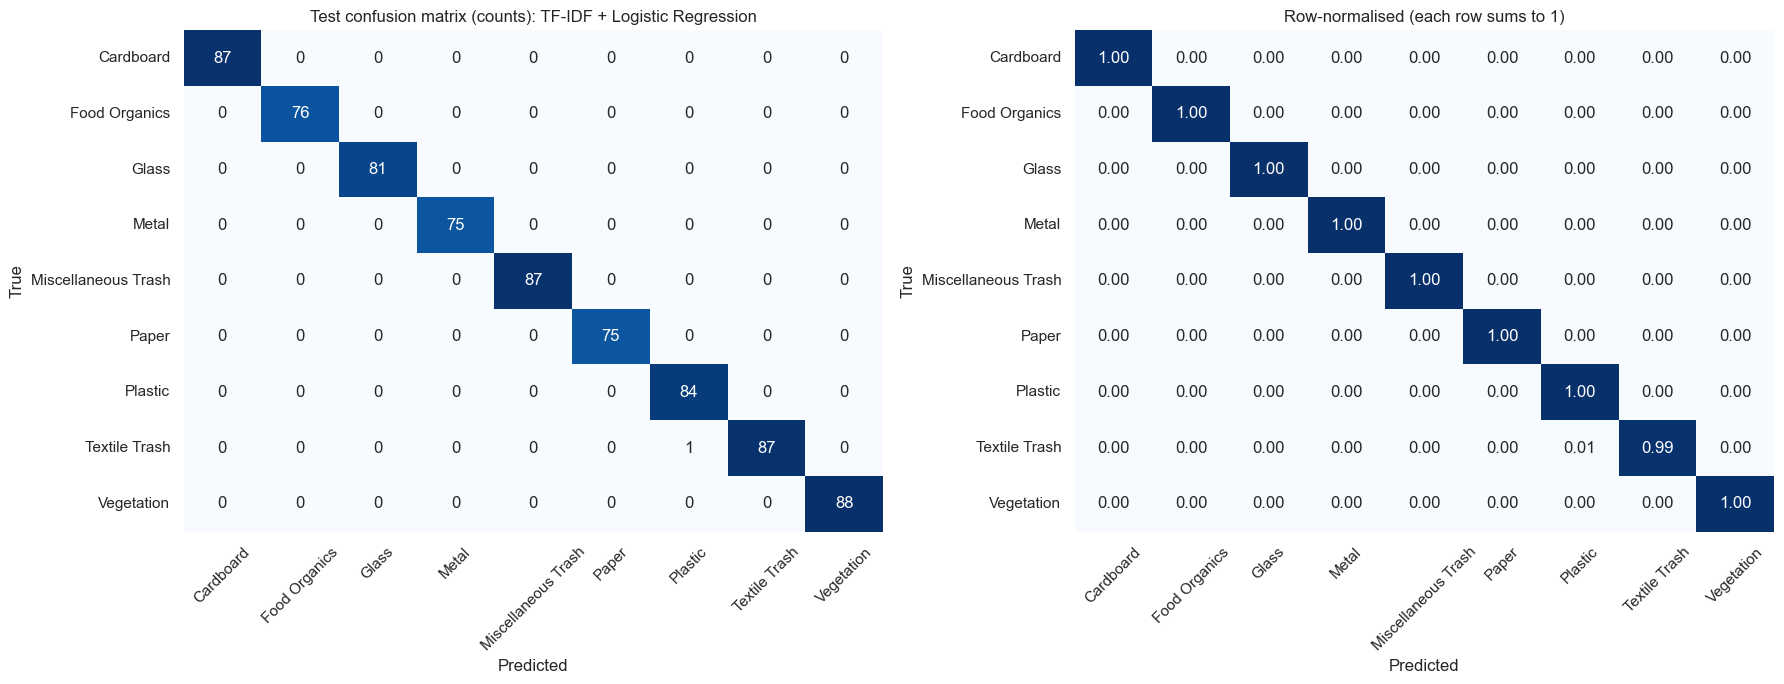

In [67]:
# 3.3f Test-set confusion matrix for the final model: counts and row-normalised (recall per class)
cm = confusion_matrix(text_test_df["category"], final_pred, labels=CATEGORIES)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CATEGORIES, yticklabels=CATEGORIES, ax=axes[0])
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=False, vmin=0, vmax=1,
            xticklabels=CATEGORIES, yticklabels=CATEGORIES, ax=axes[1])
axes[0].set_title(f"Test confusion matrix (counts): {FINAL_MODEL_NAME}")
axes[1].set_title("Row-normalised (each row sums to 1)")
for ax in axes:
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

#### 3.3g Error analysis

Three questions:

1. Which test descriptions does each model get wrong, and do the models fail on the same ones?
2. Are the errors concentrated in the material-distractor and shared-noun groups?
3. Does the final model's confidence separate right from wrong answers? Part 5 relies on this, so this is also where we set the low-confidence threshold, using validation data only.

In [68]:
# 3.3g Error analysis 1: misclassified test descriptions
names = list(CANDIDATES)

# 1. Every test description at least one model got wrong
err = text_test_df[["description", "category", "distractor", "shared_noun"]].copy()
for n in names:
    err[n] = test_pred[n]
err["models_wrong"] = np.column_stack([test_pred[n] != text_test_df["category"].values for n in names]).sum(1)
err["final_confidence"] = test_proba[FINAL_MODEL_NAME].max(1).round(3)
errors = err[err["models_wrong"] > 0].sort_values("models_wrong", ascending=False)
print(f"{len(errors)} test descriptions misclassified by at least one model")
errors

2 test descriptions misclassified by at least one model


,description,category,distractor,shared_noun,TF-IDF + Logistic Regression,BiLSTM (learned embeddings),DistilBERT (full fine-tune),models_wrong,final_confidence
5,torn industrial purple plastic rug partially filled,Textile Trash,True,False,Plastic,Textile Trash,Textile Trash,1,0.522
540,striped glass toy with food residue,Miscellaneous Trash,True,True,Miscellaneous Trash,Miscellaneous Trash,Glass,1,0.719


In [69]:
# 3.3g Error analysis 2: accuracy by description group and confused pairs
# 2. Accuracy per group of descriptions, per model
groups = {
    "all": np.ones(len(text_test_df), dtype=bool),
    "material distractor": text_test_df["distractor"].values,
    "shared noun": text_test_df["shared_noun"].values,
    "neither": ~(text_test_df["distractor"] | text_test_df["shared_noun"]).values,
}
group_table = pd.DataFrame([{"group": g, "n": int(m.sum()),
                             **{n: accuracy_score(text_test_df["category"].values[m], test_pred[n][m]) for n in names}}
                            for g, m in groups.items()])
print(group_table.round(4).to_string(index=False))

# Most frequent (true -> predicted) confusions, per model
pairs = []
for n in names:
    for t, p in zip(text_test_df["category"], test_pred[n]):
        if t != p:
            pairs.append({"model": n, "true": t, "predicted": p})
if pairs:
    print("\nConfused pairs:")
    print(pd.DataFrame(pairs).value_counts().reset_index(name="count").to_string(index=False))

              group   n  TF-IDF + Logistic Regression  BiLSTM (learned embeddings)  DistilBERT (full fine-tune)
                all 741                        0.9987                          1.0                       0.9987
material distractor  41                        0.9756                          1.0                       0.9756
        shared noun 323                        1.0000                          1.0                       0.9969
            neither 389                        1.0000                          1.0                       1.0000

Confused pairs:
                       model                true predicted  count
 DistilBERT (full fine-tune) Miscellaneous Trash     Glass      1
TF-IDF + Logistic Regression       Textile Trash   Plastic      1


LOW_CONFIDENCE = 0.86 (1st percentile of validation confidence)
Test predictions below it: 9 of 741 | errors among them: 1 of 1


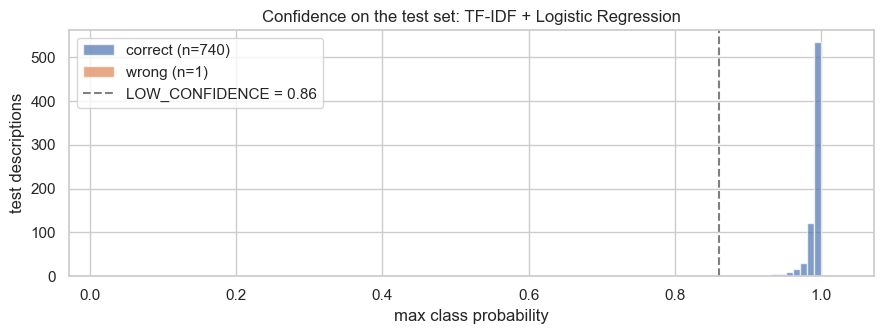

Mean confidence when correct: 0.9887
Mean confidence when wrong:   0.5222


,description,category,predicted,confidence
5,torn industrial purple plastic rug partially filled,Textile Trash,Plastic,0.522
254,large paper bed sheet,Textile Trash,Textile Trash,0.708
540,striped glass toy with food residue,Miscellaneous Trash,Miscellaneous Trash,0.719
378,oversized glass Eco-Friendly rug with product remaining,Textile Trash,Textile Trash,0.736
452,torn metal Artisanal fabric scrap,Textile Trash,Textile Trash,0.769
586,dirty small plastic Budget tool,Miscellaneous Trash,Miscellaneous Trash,0.781
45,personal green glass Eco-Friendly marker,Miscellaneous Trash,Miscellaneous Trash,0.831
199,full massive floral toy with product remaining,Miscellaneous Trash,Miscellaneous Trash,0.836
659,ripped fabric plastic-metal composite,Miscellaneous Trash,Miscellaneous Trash,0.850
493,mini yellow metal gloves,Textile Trash,Textile Trash,0.867


In [70]:
# 3.3g Error analysis 3: confidence on right vs wrong predictions
conf = test_proba[FINAL_MODEL_NAME].max(1)
correct = final_pred == text_test_df["category"].values

# Low-confidence threshold for Part 5, chosen on VALIDATION (not test):
# the 1st percentile of the final model's validation confidence, so about 1 in 100 inputs is flagged
val_conf = FINAL_PREDICT_PROBA(text_val_df["description"].tolist()).max(1)
LOW_CONFIDENCE = round(float(np.quantile(val_conf, 0.01)), 2)
flagged = conf < LOW_CONFIDENCE
print(f"LOW_CONFIDENCE = {LOW_CONFIDENCE} (1st percentile of validation confidence)")
print(f"Test predictions below it: {flagged.sum()} of {len(conf)} | errors among them: {(flagged & ~correct).sum()} of {(~correct).sum()}")

plt.figure(figsize=(9, 3.5))
plt.hist(conf[correct], bins=30, alpha=0.7, label=f"correct (n={correct.sum()})")
if (~correct).any():
    plt.hist(conf[~correct], bins=30, alpha=0.7, label=f"wrong (n={(~correct).sum()})")
plt.axvline(LOW_CONFIDENCE, ls="--", c="grey", label=f"LOW_CONFIDENCE = {LOW_CONFIDENCE}")
plt.xlabel("max class probability"); plt.ylabel("test descriptions")
plt.title(f"Confidence on the test set: {FINAL_MODEL_NAME}")
plt.legend(); plt.tight_layout(); plt.show()

print("Mean confidence when correct:", round(conf[correct].mean(), 4))
if (~correct).any():
    print("Mean confidence when wrong:  ", round(conf[~correct].mean(), 4))

# The least confident predictions, right or wrong, are the descriptions the model finds hardest
hardest = text_test_df[["description", "category"]].assign(predicted=final_pred, confidence=conf.round(3))
hardest.sort_values("confidence").head(10)

**Error analysis findings**

Test results: TF-IDF + Logistic Regression 740/741 (accuracy and macro-F1 0.9987), BiLSTM 741/741, DistilBERT 740/741. The BiLSTM was perfect on test but was not selected. The selection rule was fixed before the test set was opened, and one description out of 741 is too small a gap to override it after the fact.

Only two test descriptions caused any error, and no two models failed on the same one:

| Description | True | Wrong prediction | Model |
|---|---|---|---|
| *torn industrial purple plastic rug partially filled* | Textile Trash | Plastic (confidence 0.52) | TF-IDF + LR |
| *striped glass toy with food residue* | Miscellaneous Trash | Glass | DistilBERT |

Both are **material distractors**: a material word (*plastic*, *glass*) contradicts the item (*rug*, *toy*). The group table makes the pattern clear. Every model is perfect on descriptions with no distractor and no shared noun (389 of 389). The only drop is in the 41 material-distractor descriptions (0.976 for LR and DistilBERT). This matches the dataset's own `common_confusion` notes, which warn about mixed-material items (Metal) and hidden recyclable components inside Miscellaneous Trash.

Shared nouns turned out to be a smaller problem than expected. LR and the BiLSTM got all 323 right, and DistilBERT missed one, the glass-toy error above, which is a distractor case too. The neighbouring word (*egg carton* / *egg shells*) is enough for every model.

Confidence is informative. Mean confidence is 0.99 on correct predictions and 0.52 on the single error. Of the 10 least confident test predictions, 9 contain a material distractor (*paper bed sheet*, *glass rug*, *metal gloves*). The threshold set from validation (0.86 in our run) flags about 1% of test inputs, and the one error falls below it. Part 5 can therefore ask the resident for more detail on exactly the kind of description the model finds hard.

**Limitations**

- The descriptions are synthetic and templated, so test scores near 100% overstate real-world accuracy. The challenge set gives a more honest picture.
- Labels describe the **material**, not the disposal route. *"pizza box with food residue"* is labelled Cardboard, yet the policy documents say soiled pizza boxes go to organics or general waste. Deciding how to dispose of the item correctly is Part 4's job, using the policy text.
- The regional normalisation map is hand-written and only covers the terms listed. Words outside it rely on the model, and only DistilBERT has seen them before, through pretraining.
- Some words act as shortcuts only because of how the data was generated. *old* appears only in Textile Trash (*old t-shirt*), so the TF-IDF model labels *"old phone charger"* as Textile Trash with high confidence. A model trained on real resident text would not learn this cue.

### 3.4 Create Classification Function

`classify_waste_description` keeps the exact signature from the starter notebook. Behind it is the final model chosen in 3.3e: **TF-IDF + Logistic Regression** (C = 100, unigrams), test accuracy 0.9987.

Two helpers are added for Part 5:

- `classify_waste_description_with_confidence` returns `(category, confidence)`, which Part 5 needs for its output dictionary.
- `predict_text` is an alias, because our team RUBRIC.md uses that name.

Empty input or input that is not a string raises `ValueError`, so Part 5 can catch it and respond to the user. Inputs made of unknown words still get a category, but with low confidence. `LOW_CONFIDENCE` (set in 3.3g from validation, 0.86 in our run) is the point below which Part 5 should ask the resident for more detail.

In [71]:
# 3.4 Classification function
# LOW_CONFIDENCE was set in 3.3g from validation data (below it, Part 5 should ask for more detail)

def _check_description(description):
    if not isinstance(description, str) or not description.strip():
        raise ValueError("description must be a non-empty string")

def classify_waste_description_with_confidence(description):
    """
    Classifies a waste description and returns the probability of the predicted class.

    Args:
        description (str): Text description of waste item

    Returns:
        tuple: (predicted category (str), confidence between 0 and 1 (float))
    """
    _check_description(description)
    proba = FINAL_PREDICT_PROBA([description])[0]
    best = int(proba.argmax())
    return CATEGORIES[best], float(proba[best])

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    category, _ = classify_waste_description_with_confidence(description)
    return category

# Alias for the name used in the team rubric
predict_text = classify_waste_description

print("Final model behind classify_waste_description:", FINAL_MODEL_NAME)

Final model behind classify_waste_description: TF-IDF + Logistic Regression


In [72]:
# 3.4 Tests
# 1. Random test-set descriptions
for _, row in text_test_df.sample(5, random_state=SEED).iterrows():
    cat, p = classify_waste_description_with_confidence(row["description"])
    print(f"{'OK ' if cat == row['category'] else 'BAD'} {row['description']!r:55} -> {cat:20} ({p:.2f})  true: {row['category']}")

# 2. Resident-style inputs
print()
for text in ["used nappy", "aluminium tin of baked beans", "egg carton", "egg shells from breakfast",
             "old phone charger", "asdfgh qwerty"]:
    cat, p = classify_waste_description_with_confidence(text)
    flag = "  <- low confidence, ask for more detail" if p < LOW_CONFIDENCE else ""
    print(f"{text!r:35} -> {cat:20} ({p:.2f}){flag}")

# 3. Bad input is rejected with a clear error
print()
for bad in ["", "   ", None, 42]:
    try:
        classify_waste_description(bad)
        print(f"{bad!r}: no error raised (unexpected)")
    except ValueError as e:
        print(f"{bad!r}: ValueError -> {e}")

# 4. Contract checks for Part 5
assert all(classify_waste_description(d) in CATEGORIES for d in text_test_df["description"].head(100))
assert predict_text("glass jar") == classify_waste_description("glass jar")
t0 = time.perf_counter()
for d in text_test_df["description"].head(100):
    classify_waste_description(d)
print(f"\nAll checks passed. Average time per call: {(time.perf_counter() - t0) * 10:.1f} ms")

OK  'damaged large Local champagne bottle'                  -> Glass                (0.98)  true: Glass
OK  'medium glass rug'                                      -> Textile Trash        (0.88)  true: Textile Trash
OK  'oversized Homemade glass tabletop partially filled'    -> Glass                (0.99)  true: Glass
OK  'food packaging leaking'                                -> Cardboard            (1.00)  true: Cardboard
OK  'folded travel-sized flowers with product remaining'    -> Vegetation           (0.99)  true: Vegetation

'used nappy'                        -> Miscellaneous Trash  (0.98)
'aluminium tin of baked beans'      -> Metal                (1.00)
'egg carton'                        -> Cardboard            (1.00)
'egg shells from breakfast'         -> Food Organics        (1.00)
'old phone charger'                 -> Textile Trash        (0.98)
'asdfgh qwerty'                     -> Textile Trash        (0.28)  <- low confidence, ask for more detail

'': ValueError -> d

**Interface for Part 5**

| Function | Returns | Notes |
|---|---|---|
| `classify_waste_description(description)` | `str`, one of `CATEGORIES` | signature required by the brief |
| `classify_waste_description_with_confidence(description)` | `(str, float)` | use for the `confidence` field |
| `predict_text(description)` | `str` | alias of the first function |
| `LOW_CONFIDENCE` | `float` (0.86 in our run) | below this, ask the resident for more detail |
| `text_test_df` | DataFrame | shared text test set (same rows as Part 1's split); use its `description` and `category` columns |

All functions raise `ValueError` on empty or non-string input.